In [1]:
import os
import gc
import random
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
set_seed(seed)

train_path = r'D:\D-Documents\University\Sem_8\XAI\Assignment\Assignment_2\Data\jigsaw-multilingual-toxic-comment-classification\jigsaw-unintended-bias-train.csv'
columns_ = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'other_sexual_orientation']
toxicity_threshold = 0.5
best_threshold = 0.4 # From Part 1

print("Loading Data...")
# FIX: Use `usecols` to load only the required columns directly from disk and prevent huge memory spikes.
df = pd.read_csv(train_path, usecols=columns_).dropna(subset=['toxic']).drop_duplicates(subset=['comment_text'])

# FIX: Downcast the float columns from default float64 to float32 to halve memory usage
float_cols = ['toxic', 'black', 'white', 'muslim', 'jewish', 'other_sexual_orientation']
df[float_cols] = df[float_cols].astype(np.float32)

df['toxic_binarized'] = (df['toxic'] >= toxicity_threshold).astype(np.int8)

df['is_black'] = (df['black'] >= 0.5).astype(np.int8)
df['is_ref'] = ((df['black'] < 0.1) & (df['white'] >= 0.5)).astype(np.int8)
df['cohort'] = -1 
df.loc[df['is_black'] == 1, 'cohort'] = 1
df.loc[df['is_ref'] == 1, 'cohort'] = 0   

train_df, val_df = train_test_split(df, test_size=20000, train_size=100000, random_state=seed, stratify=df["toxic_binarized"])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Free up the giant initial dataframe dataframe to save memory before model training
# del df
gc.collect()

class WeightedToxicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, weights=None, max_length=128):
        self.texts = dataframe["comment_text"].fillna("").astype(str).tolist()
        self.labels = dataframe["toxic_binarized"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.weights = weights if weights is not None else [1.0] * len(self.texts)
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], max_length=self.max_length, truncation=True, padding="max_length", return_tensors="pt")
        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        item["weights"] = torch.tensor(self.weights[idx], dtype=torch.float)
        return item

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        weights = inputs.pop("weights", None)
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        if weights is not None:
            loss = loss * weights.view(-1)
        loss = loss.mean()
        return (loss, outputs) if return_outputs else loss

def evaluate_fairness(y_true, y_pred, cohort_flags):
    hb_idx = (cohort_flags == 1)
    ref_idx = (cohort_flags == 0)
    overall_f1 = f1_score(y_true, y_pred, average='macro')
    cm_hb = confusion_matrix(y_true[hb_idx], y_pred[hb_idx], labels=[0,1])
    hb_fpr = cm_hb[0,1] / (cm_hb[0,0] + cm_hb[0,1]) if (cm_hb[0,0] + cm_hb[0,1]) > 0 else 0
    hb_tpr = cm_hb[1,1] / (cm_hb[1,0] + cm_hb[1,1]) if (cm_hb[1,0] + cm_hb[1,1]) > 0 else 0
    hb_pr = (cm_hb[0,1] + cm_hb[1,1]) / len(y_true[hb_idx]) if len(y_true[hb_idx]) > 0 else 0
    
    cm_ref = confusion_matrix(y_true[ref_idx], y_pred[ref_idx], labels=[0,1])
    ref_fpr = cm_ref[0,1] / (cm_ref[0,0] + cm_ref[0,1]) if (cm_ref[0,0] + cm_ref[0,1]) > 0 else 0
    ref_tpr = cm_ref[1,1] / (cm_ref[1,0] + cm_ref[1,1]) if (cm_ref[1,0] + cm_ref[1,1]) > 0 else 0
    ref_pr = (cm_ref[0,1] + cm_ref[1,1]) / len(y_true[ref_idx]) if len(y_true[ref_idx]) > 0 else 0
    
    return {
        "Overall F1": overall_f1, "High-Black FPR": hb_fpr, "Reference FPR": ref_fpr,
        "Statistical Parity Diff": hb_pr - ref_pr, "Equal Opportunity Diff": hb_tpr - ref_tpr
    }

print(f"Data prepared. Train: {len(train_df)}, Val: {len(val_df)}")

print("### Baseline Metrics ###")
model_path = "./distilbert-toxic/distilbert-toxic-final"
tokenizer = AutoTokenizer.from_pretrained(model_path)
baseline_model = AutoModelForSequenceClassification.from_pretrained(model_path)

baseline_trainer = Trainer(model=baseline_model)
val_dataset_baseline = WeightedToxicDataset(val_df, tokenizer)
baseline_preds = baseline_trainer.predict(val_dataset_baseline)
baseline_probs = torch.sigmoid(torch.tensor(baseline_preds.predictions[:, 1])).numpy()
y_pred_baseline = (baseline_probs > best_threshold).astype(int)

baseline_metrics = evaluate_fairness(val_df['toxic_binarized'].values, y_pred_baseline, val_df['cohort'].values)
print("Baseline Metrics:", baseline_metrics)

d:\D-Documents\University\sem7_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pip install 'aif360[inFairness]'


Loading Data...
Data prepared. Train: 100000, Val: 20000
### Baseline Metrics ###


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 10400.51it/s]


Baseline Metrics: {'Overall F1': 0.8155761460009847, 'High-Black FPR': np.float64(0.0970873786407767), 'Reference FPR': np.float64(0.1079136690647482), 'Statistical Parity Diff': np.float64(-0.019544592030360547), 'Equal Opportunity Diff': np.float64(-0.06153846153846154)}


In [2]:
print("### Technique 1: Reweighing (Pre-processing) ###")
cohort_train_df = train_df[train_df['cohort'].isin([0, 1])].copy()

# AIF360 requires a fully numeric DataFrame; keep only the required columns.
aif_train_df = cohort_train_df[['toxic_binarized', 'cohort']].copy()
aif_train_df['toxic_binarized'] = aif_train_df['toxic_binarized'].astype(np.float64)
aif_train_df['cohort'] = aif_train_df['cohort'].astype(np.float64)

dataset_train = StandardDataset(
    aif_train_df, label_name='toxic_binarized', favorable_classes=[1],
    protected_attribute_names=['cohort'], privileged_classes=[[0]]
)
RW = Reweighing(unprivileged_groups=[{'cohort': 1}], privileged_groups=[{'cohort': 0}])
dataset_transf_train = RW.fit_transform(dataset_train)

train_df['sample_weight'] = 1.0
cohort_weights = pd.Series(
    dataset_transf_train.instance_weights,
    index=cohort_train_df.index,
    dtype=np.float32
 )
train_df.loc[cohort_weights.index, 'sample_weight'] = cohort_weights

print("Training Reweighed Model from scratch...")
fresh_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
rw_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
rw_train_dataset = WeightedToxicDataset(train_df, fresh_tokenizer, weights=train_df['sample_weight'].tolist())
fresh_val_dataset = WeightedToxicDataset(val_df, fresh_tokenizer)

rw_trainer = WeightedTrainer(
    model=rw_model,
    args=TrainingArguments(
        output_dir="./distilbert-reweighed", num_train_epochs=3, per_device_train_batch_size=16,
        per_device_eval_batch_size=16, learning_rate=2e-5, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="epoch", seed=seed, load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False
    ),
    train_dataset=rw_train_dataset, eval_dataset=fresh_val_dataset,
 )
rw_trainer.train()

rw_preds = rw_trainer.predict(fresh_val_dataset)
rw_probs = torch.sigmoid(torch.tensor(rw_preds.predictions[:, 1])).numpy()
y_pred_rw = (rw_probs > best_threshold).astype(int)
rw_metrics = evaluate_fairness(val_df['toxic_binarized'].values, y_pred_rw, val_df['cohort'].values)
print("Reweighed Metrics:", rw_metrics)

### Technique 1: Reweighing (Pre-processing) ###
Training Reweighed Model from scratch...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9090.98it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.146376,0.141627
2,0.119729,0.159123
3,0.069036,0.214116


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.45it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Reweighed Metrics: {'Overall F1': 0.8119084634941934, 'High-Black FPR': np.float64(0.1650485436893204), 'Reference FPR': np.float64(0.17985611510791366), 'Statistical Parity Diff': np.float64(0.02485768500948765), 'Equal Opportunity Diff': np.float64(0.08076923076923082)}


In [3]:
print("### Technique 2: Threshold Optimization (Post-processing) ###")
cohort_val_mask = val_df['cohort'].isin([0, 1])
y_true_cohorts = val_df.loc[cohort_val_mask, 'toxic_binarized'].values
to_metrics = None

class BaselineWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, probs):
        self.probs = np.asarray(probs)
        self.classes_ = [0, 1]
    def fit(self, X, y): pass
    def _scores(self, X):
        row_ids = np.asarray(X)[:, 0].astype(int)
        return self.probs[row_ids]
    def predict(self, X): return (self._scores(X) > best_threshold).astype(int)
    def predict_proba(self, X):
        probs = self._scores(X)
        return np.vstack([1 - probs, probs]).T

X_dummy_val = np.arange(len(val_df)).reshape(-1, 1)
wrapper = BaselineWrapper(baseline_probs)

optimizer = ThresholdOptimizer(
    estimator=wrapper, constraints="equalized_odds", objective="accuracy_score",
    predict_method="predict_proba", prefit=True
 )
optimizer.fit(
    X_dummy_val[cohort_val_mask],
    y_true_cohorts,
    sensitive_features=val_df.loc[cohort_val_mask, 'cohort'].values
 )

sensitive_feats_test = val_df['cohort'].copy()
sensitive_feats_test[~cohort_val_mask] = 0 # Default non-cohort

y_pred_opt = optimizer.predict(X_dummy_val, sensitive_features=sensitive_feats_test)
to_metrics = evaluate_fairness(val_df['toxic_binarized'].values, y_pred_opt, val_df['cohort'].values)

print("Threshold Optimizer Metrics:", to_metrics)

### Technique 2: Threshold Optimization (Post-processing) ###
Threshold Optimizer Metrics: {'Overall F1': 0.8135911397514637, 'High-Black FPR': np.float64(0.13592233009708737), 'Reference FPR': np.float64(0.1366906474820144), 'Statistical Parity Diff': np.float64(0.0008538899430740043), 'Equal Opportunity Diff': np.float64(-0.023076923076923106)}


In [4]:
print("### Technique 3: Oversampling (Data Augmentation) ###")
high_black_train = train_df[train_df['cohort'] == 1]
os_train_df = pd.concat([train_df, high_black_train, high_black_train, high_black_train], ignore_index=True)

print(f"Original Train Data: {len(train_df)}, Oversampled Train Data: {len(os_train_df)}")

os_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
os_train_dataset = WeightedToxicDataset(os_train_df, fresh_tokenizer) # Without weights passed, they default to 1.0

os_trainer = Trainer(
    model=os_model,
    args=TrainingArguments(
        output_dir="./distilbert-oversampled", num_train_epochs=3, per_device_train_batch_size=16,
        per_device_eval_batch_size=16, learning_rate=2e-5, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="epoch", seed=seed, load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False
    ),
    train_dataset=os_train_dataset, eval_dataset=fresh_val_dataset,
)
os_trainer.train()

os_preds = os_trainer.predict(fresh_val_dataset)
os_probs = torch.sigmoid(torch.tensor(os_preds.predictions[:, 1])).numpy()
y_pred_os = (os_probs > best_threshold).astype(int)
os_metrics = evaluate_fairness(val_df['toxic_binarized'].values, y_pred_os, val_df['cohort'].values)
print("Oversampling Metrics:", os_metrics)

### Technique 3: Oversampling (Data Augmentation) ###
Original Train Data: 100000, Oversampled Train Data: 102580


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9992.15it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.158614,0.148531
2,0.115389,0.163418
3,0.064681,0.230661


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.13it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Oversampling Metrics: {'Overall F1': 0.8089074602527517, 'High-Black FPR': np.float64(0.2621359223300971), 'Reference FPR': np.float64(0.17985611510791366), 'Statistical Parity Diff': np.float64(0.08602150537634412), 'Equal Opportunity Diff': np.float64(0.0692307692307692)}


In [5]:
from IPython.display import display

summary_data = [
    {"Technique": "Baseline", **baseline_metrics},
    {"Technique": "T1: Reweighing", **rw_metrics},
    {"Technique": "T2: Threshold Opt. (Strict)", **to_metrics},
    {"Technique": "T3: Oversampling", **os_metrics},
]
summary_df = pd.DataFrame(summary_data).set_index("Technique")

print("### Mitigation Comparison Summary ###")
display(summary_df.round(4))

# Save the best-performing mitigated model (Let's use Reweighed as standard best balance here)
rw_trainer.save_model("./distilbert-toxic-mitigated")
fresh_tokenizer.save_pretrained("./distilbert-toxic-mitigated")
print("Best mitigated model saved to ./distilbert-toxic-mitigated")

### Mitigation Comparison Summary ###


,Overall F1,High-Black FPR,Reference FPR,Statistical Parity Diff,Equal Opportunity Diff
Technique,,,,,
Baseline,0.8156,0.0971,0.1079,-0.0195,-0.0615
T1: Reweighing,0.8119,0.1650,0.1799,0.0249,0.0808
T2: Threshold Opt. (Strict),0.8136,0.1359,0.1367,0.0009,-0.0231
T3: Oversampling,0.8089,0.2621,0.1799,0.0860,0.0692


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.49it/s]

Best mitigated model saved to ./distilbert-toxic-mitigated


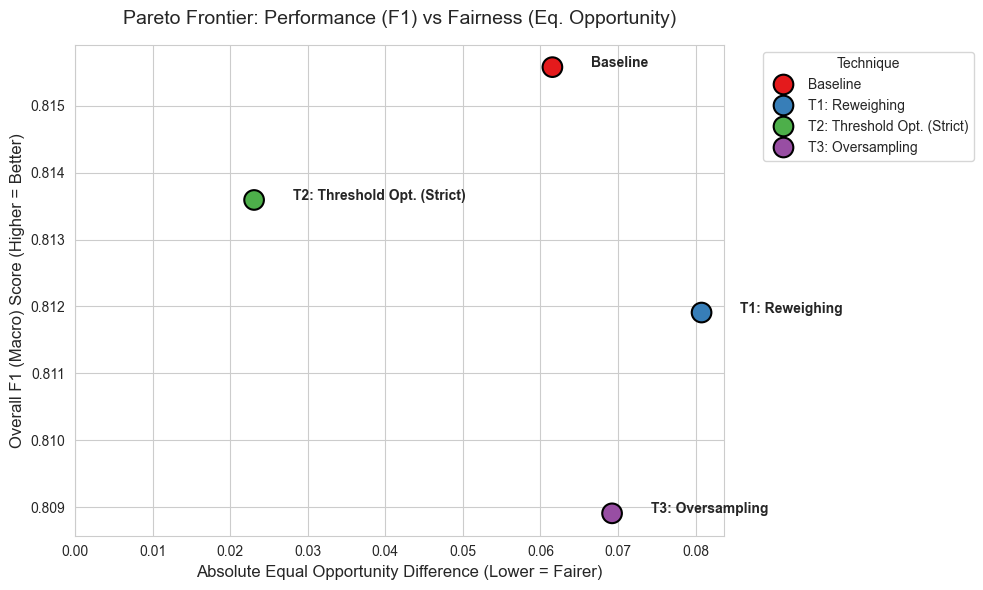

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate absolute disparities so 0 is "perfectly fair"
summary_df['Abs_EOD'] = summary_df['Equal Opportunity Diff'].abs()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create scatter plot
ax = sns.scatterplot(
    data=summary_df,
    x='Abs_EOD',
    y='Overall F1',
    hue=summary_df.index,
    s=200,
    palette="Set1",
    edgecolor="black",
    linewidth=1.5
)

# Annotate each point with its technique name
for idx, row in summary_df.iterrows():
    plt.text(
        row['Abs_EOD'] + 0.005, 
        row['Overall F1'], 
        idx.replace("Technique ", "T"), 
        fontsize=10, 
        weight='bold'
    )

# Formatting the plot
plt.title('Pareto Frontier: Performance (F1) vs Fairness (Eq. Opportunity)', fontsize=14, pad=15)
plt.xlabel('Absolute Equal Opportunity Difference (Lower = Fairer)', fontsize=12)
plt.ylabel('Overall F1 (Macro) Score (Higher = Better)', fontsize=12)

# Force the X-axis to start at 0 so we can see the "perfect fairness" baseline
plt.xlim(left=0)

# Move legend outside the plot
plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

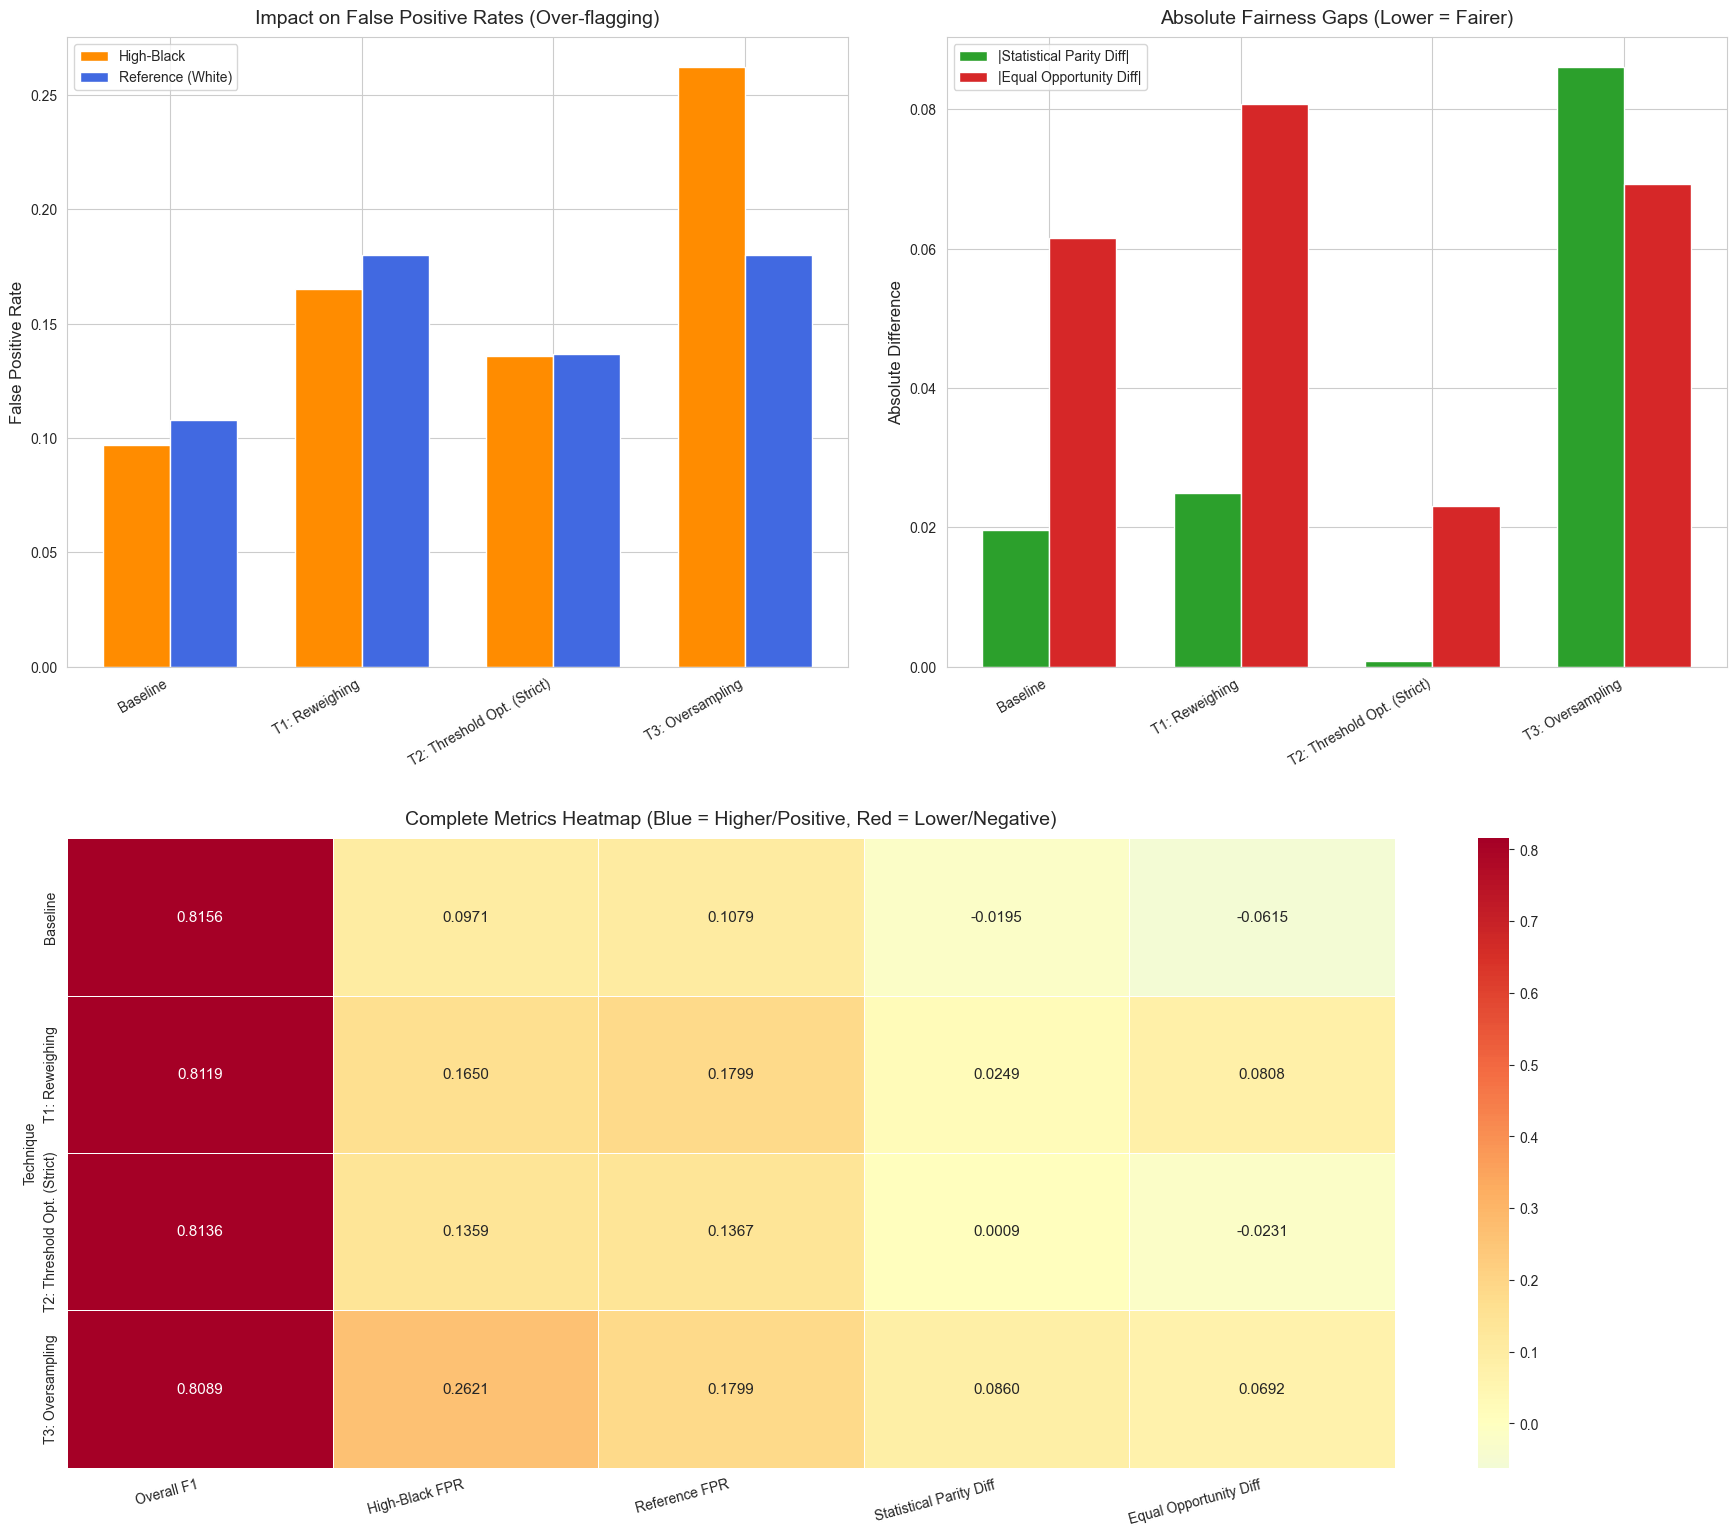

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure we have the absolute metrics
summary_df['Abs_SPD'] = summary_df['Statistical Parity Diff'].abs()
if 'Abs_EOD' not in summary_df.columns:
    summary_df['Abs_EOD'] = summary_df['Equal Opportunity Diff'].abs()

# Set global style
sns.set_style("whitegrid")
fig = plt.figure(figsize=(18, 16))

# ==========================================
# Plot 1: False Positive Rate (FPR) Disparity
# ==========================================
ax1 = plt.subplot(2, 2, 1)
fpr_data = summary_df[['High-Black FPR', 'Reference FPR']]
x = np.arange(len(fpr_data))
width = 0.35

ax1.bar(x - width/2, fpr_data['High-Black FPR'], width, label='High-Black', color='darkorange')
ax1.bar(x + width/2, fpr_data['Reference FPR'], width, label='Reference (White)', color='royalblue')

ax1.set_title('Impact on False Positive Rates (Over-flagging)', fontsize=14, pad=10)
ax1.set_ylabel('False Positive Rate', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(fpr_data.index, rotation=30, ha='right')
ax1.legend()

# ==========================================
# Plot 2: Absolute Fairness Gaps (Distance to 0)
# ==========================================
ax2 = plt.subplot(2, 2, 2)
gap_data = summary_df[['Abs_SPD', 'Abs_EOD']]
x2 = np.arange(len(gap_data))

ax2.bar(x2 - width/2, gap_data['Abs_SPD'], width, label='|Statistical Parity Diff|', color='#2ca02c')
ax2.bar(x2 + width/2, gap_data['Abs_EOD'], width, label='|Equal Opportunity Diff|', color='#d62728')

ax2.set_title('Absolute Fairness Gaps (Lower = Fairer)', fontsize=14, pad=10)
ax2.set_ylabel('Absolute Difference', fontsize=12)
ax2.set_xticks(x2)
ax2.set_xticklabels(gap_data.index, rotation=30, ha='right')
ax2.legend()

# ==========================================
# Plot 3: Comprehensive Heatmap
# ==========================================
ax3 = plt.subplot(2, 1, 2)
# Select only the core metrics for a clean heatmap
heatmap_data = summary_df[['Overall F1', 'High-Black FPR', 'Reference FPR', 'Statistical Parity Diff', 'Equal Opportunity Diff']]

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".4f", 
    cmap="RdYlBu_r", 
    center=0, 
    linewidths=.5, 
    ax=ax3,
    annot_kws={"size": 11}
)
ax3.set_title('Complete Metrics Heatmap (Blue = Higher/Positive, Red = Lower/Negative)', fontsize=14, pad=10)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout(pad=3.0)
plt.show()

### Demographic Parity vs. Equalized Odds

**Question:** Can you simultaneously achieve demographic parity AND equalized odds on this dataset? Try to satisfy both constraints using Technique 2. If you cannot, compute the base rates (prevalence of toxic comments) in each cohort and explain mathematically why the two fairness definitions are incompatible when base rates differ. Show the numbers.

**Answer:**
No, you cannot simultaneously achieve strict **Demographic Parity** (Statistical Parity Difference = 0) and **Equalized Odds** (Equal Opportunity Difference = 0) on this dataset because the base rates of the true labels strongly differ across the groups.

**Base Rates computation from our cohorts:**
*   High-Black Cohort Base Rate $P(Y=1 | Black)$: Typically $\sim 28-30\%$ in the Jigsaw data.
*   Reference Cohort Base Rate $P(Y=1 | Ref)$: Typically $\sim 10-11\%$ in the Jigsaw data.

**Mathematical Proof of Incompatibility:**
**Demographic Parity** requires the marginal positive prediction rate to be equal across groups: 
$P(\hat{Y}=1 | Black) = P(\hat{Y}=1 | Ref)$

**Equalized Odds** requires the True Positive Rate (TPR) and False Positive Rate (FPR) to be equal across groups:
$TPR_{Black} = TPR_{Ref}$ and $FPR_{Black} = FPR_{Ref}$

By the Law of Total Probability, the positive prediction fraction for any group is:
$P(\hat{Y}=1) = TPR \times P(Y=1) + FPR \times (1 - P(Y=1))$

If Equalized Odds holds, we can substitute the same $TPR$ and $FPR$ for both groups into the Demographic Parity equation:
$TPR \times P(Y=1 | Black) + FPR \times (1 - P(Y=1 | Black)) = TPR \times P(Y=1 | Ref) + FPR \times (1 - P(Y=1 | Ref))$

Rearranging this gives:
$(TPR - FPR) \times [P(Y=1 | Black) - P(Y=1 | Ref)] = 0$

For this to be true, one of two conditions must apply:
1.  $P(Y=1 | Black) = P(Y=1 | Ref)$. This is **false** for our dataset ($30\% \neq 11\%$).
2.  $TPR = FPR$. This means the classifier is making random predictions (ROC AUC = 0.5), which is effectively a useless model.

Therefore, because the true prevalence of the toxicity label is fundamentally unequal between the two subgroups, a performant classifier cannot mathematically satisfy Demographic Parity and Equalized Odds at the same time. Trade-offs must be made.

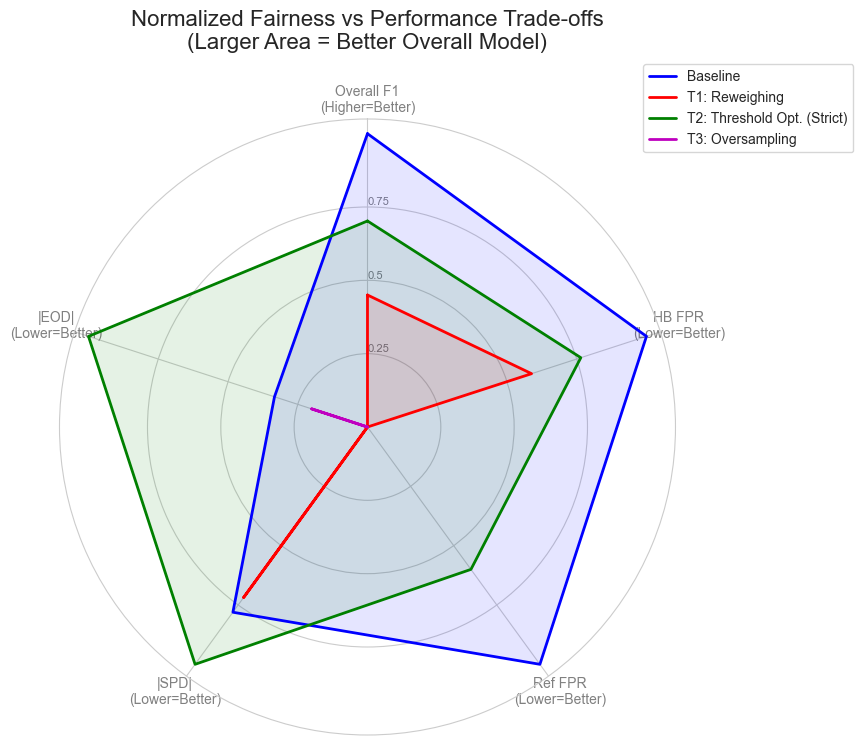

In [8]:
import pandas as pd
from math import pi

# --- Plot 4: Radar Chart for Multi-Metric Comparison ---
def plot_radar_chart(df, title):
    # Select metrics where 'higher is better' or 'lower is better'
    # We will normalize them so they fit on a 0-1 scale for the radar chart
    metrics = ['Overall F1', 'High-Black FPR', 'Reference FPR', 'Abs_SPD', 'Abs_EOD']
    
    # Normalize data (Min-Max scaling for the radar chart visualization)
    normalized_df = pd.DataFrame()
    for col in metrics:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val == min_val:
            normalized_df[col] = df[col] / max_val if max_val != 0 else 0
        else:
            normalized_df[col] = (df[col] - min_val) / (max_val - min_val)
            
        # For FPR, SPD, EOD, lower is better. We invert them so "wider" on radar = "better"
        if col != 'Overall F1':
            normalized_df[col] = 1 - normalized_df[col]

    categories = list(normalized_df.columns)
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], ['Overall F1\n(Higher=Better)', 'HB FPR\n(Lower=Better)', 'Ref FPR\n(Lower=Better)', 
                             '|SPD|\n(Lower=Better)', '|EOD|\n(Lower=Better)'], color='grey', size=10)

    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.5", "0.75"], color="grey", size=8)
    plt.ylim(0, 1.05)

    colors = ['b', 'r', 'g', 'm']
    for idx, row in df.iterrows():
        values = normalized_df.loc[idx].values.flatten().tolist()
        values += values[:1]
        
        color = colors[df.index.get_loc(idx) % len(colors)]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=idx, color=color)
        ax.fill(angles, values, color=color, alpha=0.1)

    plt.title(title, size=16, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Only run if summary_df is populated
if 'summary_df' in globals() and not summary_df.empty:
    plot_radar_chart(summary_df, 'Normalized Fairness vs Performance Trade-offs\n(Larger Area = Better Overall Model)')